# **Capstone - Machine Learning Based Intrusion Detection System**

#**Data Importing and EDA**

In [129]:
# Importing Required Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [130]:
#Pulling down notebook and datafile from GitHub
!git clone https://github.com/anthonyfeaster/UCB-AIML.git
%cd /content/UCB-AIML/Capstone
!ls
!ls data

fatal: destination path 'UCB-AIML' already exists and is not an empty directory.
/content/UCB-AIML/Capstone
capstone.ipynb	data  README.md  UCB-AIML
network_traffic_data.csv


In [131]:
#Creating a dataframe from the csv
df = pd.read_csv('data/network_traffic_data.csv')

In [132]:
df.head()

,Duration,Protocol,SourceIP,DestinationIP,SourcePort,DestinationPort,PacketCount,ByteCount,Label
0,24.077749,TCP,192.168.1.239,192.168.1.234,8055,1,827,198244,Attack
1,97.252384,ICMP,192.168.1.176,192.168.1.82,63174,687,673,1202973,Normal
2,85.842654,TCP,192.168.1.120,192.168.1.113,30873,570,319,984671,Attack
3,79.196991,UDP,192.168.1.212,192.168.1.140,4410,683,375,36284,Normal
4,34.928018,TCP,192.168.1.17,192.168.1.223,4702,989,465,817463,Normal


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Duration         2000 non-null   float64
 1   Protocol         2000 non-null   object 
 2   SourceIP         2000 non-null   object 
 3   DestinationIP    2000 non-null   object 
 4   SourcePort       2000 non-null   int64  
 5   DestinationPort  2000 non-null   int64  
 6   PacketCount      2000 non-null   int64  
 7   ByteCount        2000 non-null   int64  
 8   Label            2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [134]:
#Printing Number of Rows and Columns plus Column Names
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f"Column Names: {df.columns.tolist()}")

Rows: 2000, Columns: 9
Column Names: ['Duration', 'Protocol', 'SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'PacketCount', 'ByteCount', 'Label']


In [135]:
df.describe(include='object')

,Protocol,SourceIP,DestinationIP,Label
count,2000,2000,2000,2000
unique,3,255,255,2
top,TCP,192.168.1.177,192.168.1.226,Attack
freq,690,16,17,1022


In [136]:
#Renaming the traffic classification to industry standard terms
df['Label'] = df['Label'].replace({
    'Normal': 'Benign',
    'Attack': 'Malicious'
})

In [137]:
traffic_summary = df['Label'].value_counts().reset_index()
traffic_summary.columns = ['Traffic', 'Count']
traffic_summary['Percentage'] = (traffic_summary['Count'] / traffic_summary['Count'].sum() * 100).map("{:.2f}%".format)

print(traffic_summary)

     Traffic  Count Percentage
0  Malicious   1022     51.10%
1     Benign    978     48.90%


In [138]:
protocol_summary = df['Protocol'].value_counts().reset_index()
protocol_summary.columns = ['Protocol', 'Count']
protocol_summary['Percentage'] = (protocol_summary['Count'] / protocol_summary['Count'].sum() * 100).map("{:.2f}%".format)

protocol_summary

,Protocol,Count,Percentage
0,TCP,690,34.50%
1,ICMP,658,32.90%
2,UDP,652,32.60%


In [139]:
#Looking for Missing Values
df.isnull().sum()

,0
Duration,0
Protocol,0
SourceIP,0
DestinationIP,0
SourcePort,0
DestinationPort,0
PacketCount,0
ByteCount,0
Label,0


In [140]:
# Checking for Duplicate Values

df.duplicated().sum()

np.int64(0)

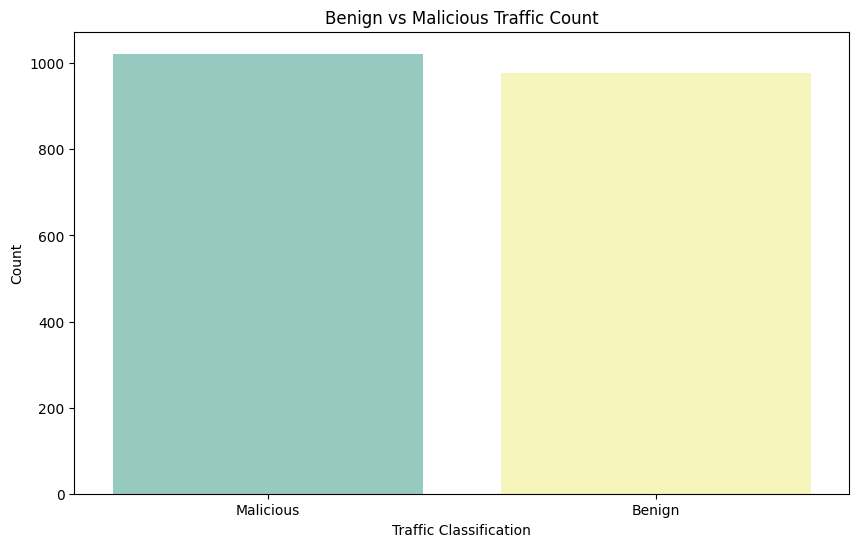

In [141]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='Set3', hue='Label')
plt.title('Benign vs Malicious Traffic Count')
plt.xlabel('Traffic Classification')
plt.ylabel('Count')
plt.show()


Max Malicious Traffic Count for Any Destination Port: 8.0



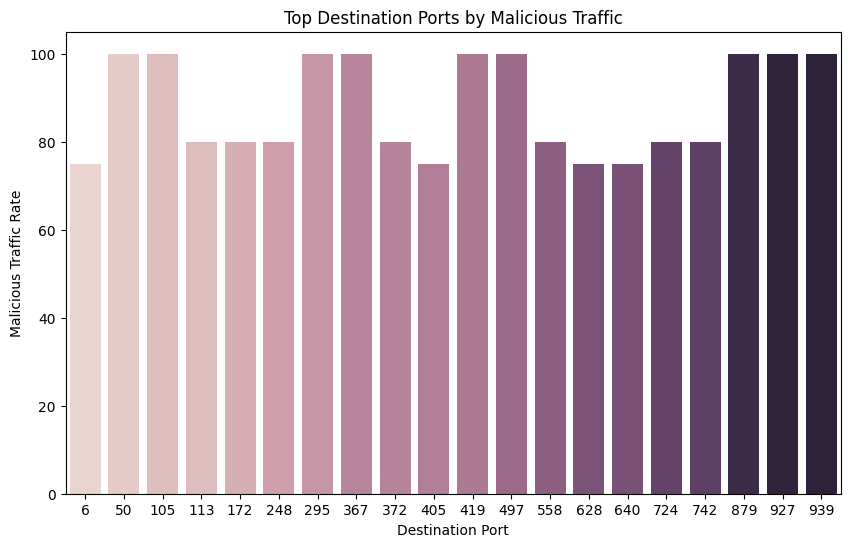

In [142]:
port_summary = df.groupby('DestinationPort')['Label'].value_counts().unstack().fillna(0)
#port_summary_src = df.groupby('SourcePort')['Label'].value_counts().unstack().fillna(0)

port_summary['Total_Traffic'] = port_summary.sum(axis=1)
#port_summary_src['Total_Traffic'] = port_summary_src.sum(axis=1)


#print(port_summary['Total_Traffic'].describe())
print(f"\nMax Malicious Traffic Count for Any Destination Port: {port_summary['Total_Traffic'].max()}")
#print(f"Max Malicious Traffic Count for Any Source Port: {port_summary_src['Total_Traffic'].min()}")
print()
port_summary['MaliciousPCT'] = ((port_summary['Malicious']) / (port_summary['Total_Traffic']) * 100)#.map("{:.2f}%".format)
port_summary_fld = port_summary[port_summary['Total_Traffic'] > 3]
top_malicious_ports = port_summary_fld.sort_values(by='MaliciousPCT', ascending=False).head(20).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=top_malicious_ports, x='DestinationPort', y='MaliciousPCT', hue='DestinationPort', legend=False)#palette='Set2')
plt.title('Top Destination Ports by Malicious Traffic')
plt.xlabel('Destination Port')
plt.ylabel('Malicious Traffic Rate')
plt.show()


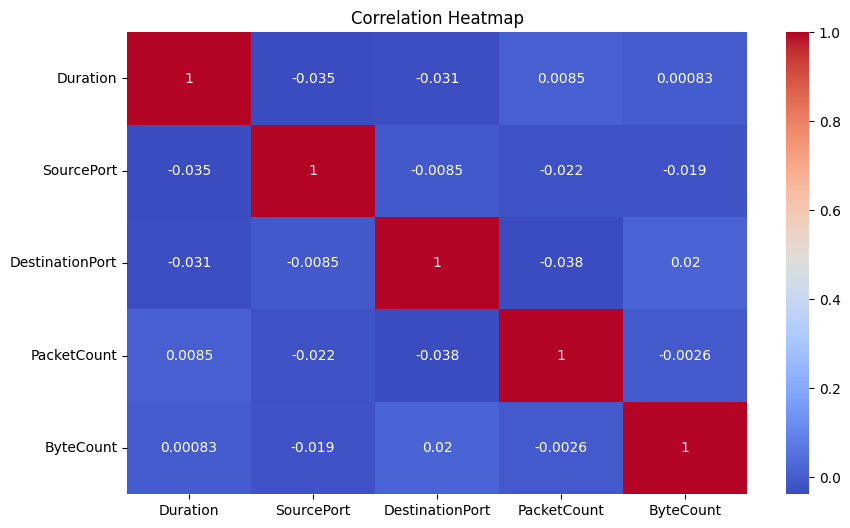

In [143]:
numerical_columns = ["Duration", "SourcePort", "DestinationPort", "PacketCount", "ByteCount"]

plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [144]:
plt.figure(figsize=(10, 6))
sn

NameError: name 'sn' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
df['DurationMinutes'] = df['Duration'] / 60
df['PacketCountPerMinute'] = df['PacketCount'] / df['DurationMinutes']

df[['Duration', 'DurationMinutes', 'PacketCount', 'PacketCountPerMinute']].head(20)

In [ ]:
src_duration_fld = df.groupby('SourceIP')['Duration'].agg(FlowCount='count', AverageDuration='mean', TotalDuration="sum").reset_index()
src_duration_fld = src_duration_fld.sort_values(by='AverageDuration', ascending=False)

src_duration_fld.head(10)

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(x='AverageDuration', y='SourceIP', data=src_duration_fld.head(10))
plt.title('Top 10 Source IPs by Average Duration')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Source IP')
plt.show()

In [ ]:
dst_duration_fld = df.groupby('DestinationIP')['Duration'].agg(FlowCount='count', AverageDuration='mean', TotalDuration="sum").reset_index()
dst_duration_fld = dst_duration_fld.sort_values(by='AverageDuration', ascending=False)

dst_duration_fld.head(10)


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AverageDuration', y='DestinationIP', data=dst_duration_fld.head(10))
plt.title('Top 10 Destination IPs by Average Duration')
plt.xlabel('Average Duration (seconds)')
plt.ylabel('Destination IP')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Protocol', data=df, palette='rocket', hue='Protocol')
plt.title('Protocol Distribution')
plt.xlabel('Protocol Types')
plt.ylabel('Count')
plt.show()
plt

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration', y='ByteCount', data=df, hue='Label')
plt.title('Duration vs Byte Count')
plt.xlabel('Duration (seconds)')
plt.ylabel('Byte Count')
plt.show()

The Duration versus Byte Count scatterplot does not show a clear correlation between benign and malicious traffic

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PacketCount', y='ByteCount', data=df, hue='Label', palette='rocket')
plt.title('Packet Count vs Byte Count')
plt.xlabel('Packet Count')
plt.ylabel('Byte Count')
plt.show()

The Packet Count versus Byte Count scatterplot does not show a clear correlation between benign and malicious traffic

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SourcePort', y='DestinationPort', data=df, hue='Label', palette='Set1')
plt.title('Source Port vs Destination Port)')
plt.xlabel('Source Port')
plt.ylabel('Destination Port')
plt.show()

The Source Port versus Destination Port scatterplot does not show a clear correlation between benign and malicious traffic

In [ ]:
def categorize_port(port):
    if port <= 1023:
        return 'Well-Known Ports'
    elif port <= 49151:
        return 'Registered Ports'
    else:
        return 'Dynamic/Private Ports'

df['SourcePortCategory'] = df['SourcePort'].apply(categorize_port)
df['DestinationPortCategory'] = df['DestinationPort'].apply(categorize_port)

plt.figure(figsize=(10, 6))
sns.countplot(x='SourcePortCategory', data=df, hue='Label', palette='Set1')
plt.title('Source Port Category Distribution')
plt.xlabel('Source Port Category')
plt.ylabel('Count')
plt.show()


In [ ]:
#Testing the accuracy of the def
print(categorize_port(80))
print(categorize_port(443))
print(categorize_port(12000))
print(categorize_port(53))
print(categorize_port(1024))

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='DestinationPortCategory', data=df, hue='Label', palette='Set1')
plt.title('Destination Port Category Distribution')
plt.xlabel('Destination Port Category')
plt.ylabel('Count')
plt.show()

In [ ]:
#Calculating Q1, Q3 & IQR
Q1 = df['PacketCount'].quantile(0.25)
Q3 = df['PacketCount'].quantile(0.75)
IQR = Q3 - Q1

#Defining Bounds
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[(df['PacketCount'] > upper_bound) | (df['PacketCount'] < lower_bound)]

print(f'Number of Outliers: {len(outliers)}')
print(f'Lower Bound: {lower_bound}, Upper Bound: {upper_bound}')

In [ ]:
BQ1 = df['ByteCount'].quantile(0.25)
BQ3 = df['ByteCount'].quantile(0.75)
BIQR = BQ3 - BQ1

#Defining Bounds
bupper_bound = BQ3 + 1.5 * BIQR
blower_bound = BQ1 - 1.5 * BIQR

boutliers = df[(df['ByteCount'] > bupper_bound) | (df['ByteCount'] < blower_bound)]

print(f'Number of Outliers: {len(boutliers)}')
print(f'Lower Bound: {blower_bound}, Upper Bound: {bupper_bound}')

In [ ]:
outlier_summary = []

for col in ['PacketCount', 'ByteCount', 'Duration']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    outliers = df[(df[col] > upper_bound) | (df[col] < lower_bound)]

    outlier_summary.append({
        'Column': col,
        'Number of Outliers': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Percentage of Outliers': round(len(outliers) / len(df) * 100, 2)
    })

    print(f'Number of Outliers for {col}: {len(outliers)}')
pd.DataFrame(outlier_summary)

Text

In [ ]:
X = df.drop(columns=['Label', 'SourceIP', 'DestinationIP'])
y = df['Label']

Dropping the SourceIP and DestinationIP features so the model doesnt memorizes the raw IP addresses

# **Modeling**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#df.columns.to_list()

In [ ]:
df.dtypes

In [ ]:
numeric_features = ['Duration', 'DestinationPort', 'SourcePort', 'PacketCount', 'ByteCount', 'DurationMinutes', 'PacketCountPerMinute']
categorical_features = ['Protocol', 'SourcePortCategory', 'DestinationPortCategory']

num = X.select_dtypes(include=['int64', 'float64']).columns
cat = X.select_dtypes(include=['object']).columns

print(f'Numerical Features: {num}')
print(f'Categorical Features: {cat}')

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

In [ ]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_prediction = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_prediction)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_prediction)
print(f"Baseline Accuracy: {baseline_accuracy}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy * 100:.2f}%")

In [ ]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)
rf_model.score(X_test, y_test)